# XGBOOST MODELS FOR CREDIT EVALUATION

## IMPORTS AND DATA PREPARATION

### IMPORTS

In [1]:
# file-path handling
from pathlib import Path

# Utilities for data management
import numpy as np
import pandas as pd

# XGBoost classifier model class
from xgboost import XGBClassifier


# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

# Chart plotting
import matplotlib.pyplot as plt
import seaborn as sns

### PATHS

In [2]:
# Paths to train / validate / test data
OUTPUT_DIR = Path("../data")
TRAIN_PATH = OUTPUT_DIR / "train.csv"
VALIDATE_PATH = OUTPUT_DIR / "validate.csv"
TEST_PATH = OUTPUT_DIR / "test.csv"

# Paths to xgboost model outputs
XGBOOST_OUTPUT_DIR = Path("../output/xgboost")
XGBOOST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_RESULTS_CSV = XGBOOST_OUTPUT_DIR / "xgb_baseline_validation_results.csv"
TUNING_RESULTS_CSV = XGBOOST_OUTPUT_DIR / "xgb_unconstrained_tuning_results_validation.csv"
VALIDATION_COMPARE_CSV = XGBOOST_OUTPUT_DIR / "xgb_unconstrained_validation_comparison.csv"
SELECTED_MODEL_CSV = XGBOOST_OUTPUT_DIR / "xgb_unconstrained_selected_model_validation.csv"


### DATA VALIDATION

In [3]:
# Load data splits to pandas (no low mem for better typing when loading to df)
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
validate_df = pd.read_csv(VALIDATE_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)

# Data shape prints (samples, features)
print("Train shape:   ", train_df.shape)
print("Validate shape:", validate_df.shape)
print("Test shape:    ", test_df.shape)

Train shape:    (215137, 33)
Validate shape: (46101, 33)
Test shape:     (46101, 33)


Splits are correct (70% / 15% / 15%)

No. of Features match preprocesing output (33)

In [4]:
# Validate data loaded (after project-level preprocessing - see preprocess-data.ipynb)

# Create resuable constants for label and ID
TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"

# Confirm features and order consistent across splits
print("Train/validate columns match:", list(train_df.columns) == list(validate_df.columns))
print("Train/test columns match:    ", list(train_df.columns) == list(test_df.columns))

# Confirm class imbalance (already stratified split)
print("\nDefault rate by split:")
print("Train:   ", train_df[TARGET_COLUMN].mean())
print("Validate:", validate_df[TARGET_COLUMN].mean())
print("Test:    ", test_df[TARGET_COLUMN].mean())

# Check dtypes (esp for categorical features still strings after preprocessing)

# Group for dtype: [list of columns]
dtype_to_columns = (
    train_df.dtypes
    .astype(str)                                # Convert dtype objects to readable strings
    .groupby(train_df.dtypes.astype(str))       # Group columns by dtype
    .apply(lambda s: sorted(s.index.tolist()))  # Collect and sort column names in each dtype group
)

print("\nFeatures by dtype:")
for dtype_name, columns in dtype_to_columns.items():
    print(f"{dtype_name}: {columns}")



Train/validate columns match: True
Train/test columns match:     True

Default rate by split:
Train:    0.08072995347150885
Validate: 0.08073577579662046
Test:     0.08071408429318236

Features by dtype:
float64: ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE']
int64: ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'SK_ID_CURR', 'TARGET']
str: ['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


Cols match
Class imbalance consistent across splits but (!) very pronounced

NOTE: Project-level preproc essing does not remove missing values
- Numerical: NaNs stayed
- Categorical: Replaced by placeholder "MISSING" or imputed from mean and missing flag feature created

XGBoost can handle and use signal from missing values e.g. may learn thinner credit history, discern car ownership etc, so no need to process further



### PREP DATA FOR MODEL TRAINING

##### Separate labels (TARGET)

In [5]:
# Separate labels y
y_train = train_df[TARGET_COLUMN].astype(int).copy()
y_val = validate_df[TARGET_COLUMN].astype(int).copy()
y_test = test_df[TARGET_COLUMN].astype(int).copy()

# Remove labels and IDs to prep samples for training
X_train = train_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_val = validate_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_test = test_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()

# Print shapes (still dfs)
print(f"X_train | shape: {X_train.shape}  | type: {type(X_train)}")
print(f"X_val   | shape: {X_val.shape}    | type: {type(X_val)}")
print(f"X_test  | shape: {X_test.shape}   | type: {type(X_test)}")
print()
print(f"y_train | shape: {y_train.shape}  | type: {type(y_train)}")
print(f"y_val   | shape: {y_val.shape}    | type: {type(y_val)}")
print(f"y_test  | shape: {y_test.shape}   | type: {type(y_test)}")

X_train | shape: (215137, 31)  | type: <class 'pandas.DataFrame'>
X_val   | shape: (46101, 31)    | type: <class 'pandas.DataFrame'>
X_test  | shape: (46101, 31)   | type: <class 'pandas.DataFrame'>

y_train | shape: (215137,)  | type: <class 'pandas.Series'>
y_val   | shape: (46101,)    | type: <class 'pandas.Series'>
y_test  | shape: (46101,)   | type: <class 'pandas.Series'>


##### Convert categorical features to one-hot encodings

In [6]:
# Store list of categorical vs num features
categorical_columns = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_columns = [col for col in X_train.columns if col not in categorical_columns]

# Print and check
print("\n# numeric columns:", len(numeric_columns))
print("Numeric columns:")
print(numeric_columns)

print("\n# categorical columns:", len(categorical_columns))
print("Categorical columns:")
print(categorical_columns)

# One-hot encode categorical columns with pd.get_dumies (including "MISSING")
X_train_encoded = pd.get_dummies(
    X_train,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

X_val_encoded = pd.get_dummies(
    X_val,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

print("\nEncoded X_train shape:", X_train_encoded.shape)
print("Encoded X_val shape:  ", X_val_encoded.shape)
print("Encoded X_test shape: ", X_test_encoded.shape)


# numeric columns: 25
Numeric columns:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

# categorical columns: 6
Categorical columns:
['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

Encoded X_train shape: (215137, 127)
Encoded X_val shape:   (46101, 126)
Encoded X_test shape:  (46101, 124)


 Features before encoding: Total cat + num features = 31 (correct)

 Note: per above for num features we keep NaNs for XGBoost to handle

 (!) Encoded splits dfs have different # features (due to diff cat values) so need to align next

 ##### Align # features across splits

In [7]:
# Encoded coding split is main schema - no change
X_train_ready = X_train_encoded.copy()

# Rebuild encoded validation and test sets to match train schema (fills with dummy features full of zeroes)
X_val_ready = X_val_encoded.reindex(columns=X_train_ready.columns, fill_value=0)
X_test_ready = X_test_encoded.reindex(columns=X_train_ready.columns, fill_value=0)

# Check #features match across splits
print("Train/validate columns match:", list(X_train_ready.columns) == list(X_val_ready.columns))
print("Train/test columns match:    ", list(X_train_ready.columns) == list(X_test_ready.columns))
print("\nFinal shapes:")
print("X_train_ready:", X_train_ready.shape)
print("X_val_ready:  ", X_val_ready.shape)

Train/validate columns match: True
Train/test columns match:     True

Final shapes:
X_train_ready: (215137, 127)
X_val_ready:   (46101, 127)


In [8]:
# Check no object/string dtype features left
for split, X in {
    "train": X_train_ready,
    "validate": X_val_ready,
    "test": X_test_ready,
}.items():
    # Group for dtype: [list of columns]
    dtype_to_columns = (
        X.dtypes
        .astype(str)                                # Convert dtype objects to readable strings
        .groupby(X.dtypes.astype(str))              # Group columns by dtype
        .apply(lambda s: sorted(s.index.tolist()))  # Collect and sort column names in each dtype group
    )
    print(f"\n{split} features by dtype:")
    for dtype_name, columns in dtype_to_columns.items():
        print(f"{dtype_name}: {columns}")

# Store final cols orders (for when intorducing monotonic constraint)
feature_names = X_train_ready.columns.tolist()



train features by dtype:
float64: ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE']
int64: ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE_Academic degree', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Civil marriage', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Unknown', 'NAME_FAMILY_STATUS_Widow', 'NAME_HOUSING_TYPE_Co-o

Confirmed: Cols are all numerical

Col order stored for constrained model

Ready for training

## EVALUATION METRICS

(Note: Same for constrained and unconstrained models)

### Kolmogorov-Smirnov (KS) Stat

Measures the maximum separation between the cumulative score distributions of defaulters and non-defaulters

i.e. shows how well the model distinguishes higher-risk borrowers from lower-risk borrowers at the threshold where that separation is greatest

In [9]:
# Helper func to compute KS stat for binary classification
def compute_ks(y_true, y_score):
    """
    Returns maximum absolute separation between those two curves as float

    """
    # Convert inputs to pd series for sorting and cumm sum
    df_ks = pd.DataFrame({
        "y_true": pd.Series(y_true).reset_index(drop=True),
        "y_score": pd.Series(y_score).reset_index(drop=True)
    })

    # Sort descending by predicted score to move from highest to lowest risk observations
    df_ks = df_ks.sort_values("y_score", ascending=False).reset_index(drop=True)

    # Count total positives and negatives
    total_positives = (df_ks["y_true"] == 1).sum()
    total_negatives = (df_ks["y_true"] == 0).sum()

    # defensive code for cases where one class is missing
    if total_positives == 0 or total_negatives == 0:
        return np.nan

    # Build cumulative positive and negative shares
    df_ks["cum_positives"] = (df_ks["y_true"] == 1).cumsum() / total_positives
    df_ks["cum_negatives"] = (df_ks["y_true"] == 0).cumsum() / total_negatives

    # Store KS as maximum gap between cumulative curves
    ks_stat = np.max(np.abs(df_ks["cum_positives"] - df_ks["cum_negatives"]))

    return ks_stat

### Eval Helpers

##### Compute metrics

Helper func to evaluate fitted model with metrics:
- ROC-AUC: how well model ranks true defaulters over non-defaulters across classification thresholds
- PR-AUC: tradeoff between precision and recall (esp important here given class imbalance (rare defaults))
- Brier Score: how close predicted default probabilities are to actual outcomes
- KS Statistic: per above, maximum separation between cumulative distributions of defaulters and non-defaulters when ranked by predicted risk

In [10]:

def evaluate_binary_model(model, X, y, split_name, model_name):
    """
    Evaluates trained model, returns dict with metrics and metadata
    (Uses sklearn.metrics methods imported above to compute metrics)
    """
    # Predict probabilities for the positive class (default = 1)
    y_proba = model.predict_proba(X)[:, 1]

    # Compute eval metrics
    roc_auc = roc_auc_score(y, y_proba)
    pr_auc = average_precision_score(y, y_proba)
    brier = brier_score_loss(y, y_proba)
    ks = compute_ks(y, y_proba)

    # Extract best boosting iteration (incl with early stopping)
    # Ie boosting round at which validation performance peaked before training stopped improving
    best_iteration = getattr(model, "best_iteration", None)

    result_dict = {
        "model_name": model_name,
        "split": split_name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier_score": brier,
        "ks_stat": ks,
        "best_iteration": best_iteration
    }

    return result_dict

##### Plots

In [11]:
# ROC curves
def plot_roc_curves(curves_dict, title):

    plt.figure(figsize=(8, 6))

    for label, (y_true, y_proba) in curves_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_value = roc_auc_score(y_true, y_proba)

        # Plot each ROC curve with its AUC in the legend
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_value:.4f})")

    # Plot the random-classifier diagonal baseline
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Precision-Recall curves
def plot_pr_curves(curves_dict, title):

    plt.figure(figsize=(8, 6))

    for label, (y_true, y_proba) in curves_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        pr_auc_value = average_precision_score(y_true, y_proba)

        # Plot each PR curve with its average precision in the legend
        plt.plot(recall, precision, label=f"{label} (PR-AUC = {pr_auc_value:.4f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



# Plot a simple bar chart comparing metrics across models to compare
# - baselines vs tuned
# - unconstrained vs constrained
def plot_metric_comparison(results_df, split_name, metric_name, title):

    plot_df = results_df[results_df["split"] == split_name].copy()

    plt.figure(figsize=(8, 5))
    sns.barplot(data=plot_df, x="model_name", y=metric_name)

    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(metric_name)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

In [12]:

# Helper func to plot a two model comparison (takes a clean df with two rows with model names and metrics)
def plot_two_model_comparison(
    compare_df,
    value_col,
    title,
    x_label=None,
    as_percent=False,
    decimals=4
):

    # Keep only the two columns we need and make a copy so plotting
    # does not accidentally modify the original dataframe
    plot_df = compare_df[["model_name", value_col]].copy()

    # Convert values to float for plotting
    raw_values = plot_df[value_col].astype(float).to_numpy()

    # Optionally convert to percentages for display
    display_values = raw_values * 100 if as_percent else raw_values

    # Extract model names in display order
    model_names = plot_df["model_name"].tolist()

    # Y positions for the two models
    y_pos = np.arange(len(plot_df))

    # Build a tight x-axis range around the observed values so small differences are visible without exaggerating them too much
    x_min = display_values.min()
    x_max = display_values.max()
    x_span = x_max - x_min

    # If values are extremely close, use a small minimum padding
    padding = max(x_span * 0.35, 0.001 if not as_percent else 0.05)

    plt.figure(figsize=(8, 2.8))

    # Draw a line connecting the two points to emphasize the gap
    plt.plot(display_values, y_pos, linewidth=1, alpha=0.7)

    # Draw the points themselves
    plt.scatter(display_values, y_pos, s=80)

    # Add exact numeric labels next to each point
    for x, y in zip(display_values, y_pos):
        if as_percent:
            label = f"{x:.{decimals}f}%"
        else:
            label = f"{x:.{decimals}f}"

        plt.text(
            x + padding * 0.05,
            y,
            label,
            va="center"
        )

    # Set y-axis labels to model names
    plt.yticks(y_pos, model_names)

    # Tight x-limits around the two values
    plt.xlim(x_min - padding, x_max + padding)

    # Axis labels and title
    plt.xlabel(x_label if x_label is not None else value_col)
    plt.title(title)

    # Light grid only on x-axis
    plt.grid(True, axis="x", alpha=0.3)

    plt.show()

## UNCONSTRAINED XGBOOST MODEL

### First Trainning Run (No Hyperparameter Tuning)

In [13]:
# Define first-pass unconstrained XGBoost baseline model
xgb_baseline = XGBClassifier(
    objective="binary:logistic",    # Setting goal as binary pred
    eval_metric="aucpr",            # PR-AUC as primary eval metric given class imbalance (others computed with helpers outside)
    n_estimators=1000,              # Max no. of trees wide (sequential boosting rounds) (set high to likely let early stopping control actual num)
    early_stopping_rounds=50,       # Stop early after n rounds if validation metric doesn't improve
    learning_rate=0.05,             # Scaling factor applied to each new tree's contribution to the final prediction (step size)
    max_depth=4,                    # Max no. of trees deep (set low for xgboost - focus on sequential improvement ie estimators vs deep complexity)
    min_child_weight=5,             # Only create new branch big enough group of samples
    subsample=0.8,                  # Fraction of sample rows sampled for each boosting round (adds regularization / reduces overfitting)
    colsample_bytree=0.8,           # Fraction of features sampled when building each tree (also adds regularization / reduces overfitting)
    reg_lambda=1.0,                 # L2 regularization strength on leaf weights (higher = more shrinkage / less overfitting)
    tree_method="hist",             # Use histogram-based tree construction (faster / more efficient for large tabular datasets)
    device="cuda",                  # Use GPU
    random_state=42,                # Seed for reproducibility
    n_jobs=-1                       # Use all available CPU threads (inly for CPU-side work (per above gpu used in paralalizable training))
)

# Fit unconstrained baseline model using validation set for early stopping
xgb_baseline.fit(
    X_train_ready,
    y_train,
    eval_set=[(X_val_ready, y_val)],  # Validation set used for early stopping
    verbose=False                     # Keep notebook output clean
)


# Print boosting round at which validation performance was best under early stopping
# I.e. how many trees were useful before further boosting stopped helping
print(f"Baseline best iteration: {xgb_baseline.best_iteration}")

# Print highest validation PR-AUC reached
print(f"Baseline best score: {xgb_baseline.best_score}")

# Store predicted probabilities to plot ROC and PR curves
baseline_val_prob = xgb_baseline.predict_proba(X_val_ready)[:, 1]

Baseline best iteration: 830
Baseline best score: 0.23651913400539737


/home/jlsm/ml/credit-risk-model-constraint-eval/venv/lib/python3.13/site-packages/xgboost/core.py:751: UserWarning: [17:51:38] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [14]:
# Evaluate the fitted baseline on validation split pre-hyperparam-tuning
baseline_val_result = evaluate_binary_model(
    model=xgb_baseline,
    X=X_val_ready,
    y=y_val,
    split_name="validation",
    model_name="xgb_unconstrained_baseline"
)

results_df = pd.DataFrame([baseline_val_result])

# Save baseline validation results to CSV
results_df.to_csv(BASELINE_RESULTS_CSV, index=False)
print("Saved: xgb_baseline_validation_results.csv")

results_df

Saved: xgb_baseline_validation_results.csv


,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration
0,xgb_unconstrained_baseline,validation,0.753768,0.236797,0.068078,0.376673,830


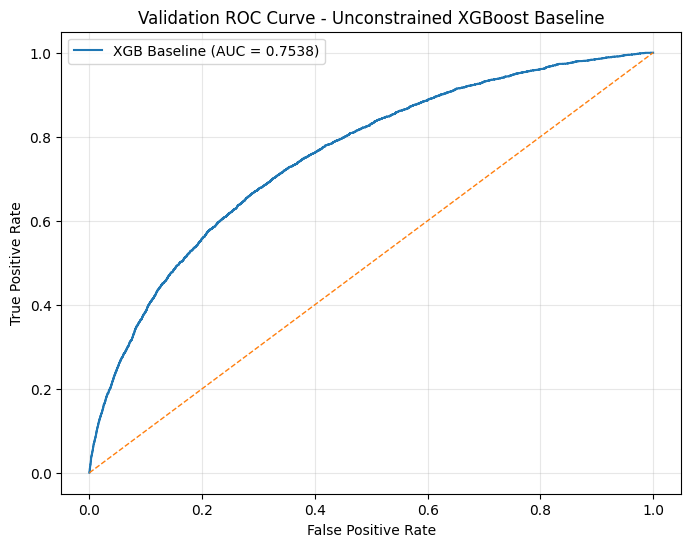

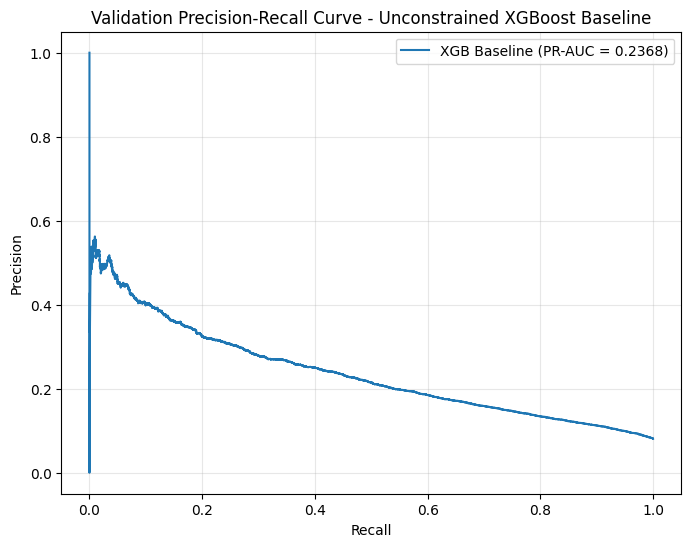

In [15]:
# Plot ROC and PR curves for the untuned baseline model on the validation set
plot_roc_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob)
    },
    title="Validation ROC Curve - Unconstrained XGBoost Baseline"
)

plot_pr_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob)
    },
    title="Validation Precision-Recall Curve - Unconstrained XGBoost Baseline"
)

### Hyperparameter Tuning

##### Approach:

Two-stage tuning design:

First, tune main tree-complexity controls:

* max_depth
* min_child_weight

These parameters most directly determine how locally complex each tree can become and how easily the model creates additional tree splits, so they are the main controls over whether the model underfits by being too rigid or overfits by learning patterns that are too specific to the training data.

Then, fix the optimal values for max_depth and min_child_weight and tune the main boosting and regularization controls:

* learning_rate
* subsample
* colsample_bytree
* reg_lambda

This staged design is intended to separate two related but conceptually distinct questions:

* first, what level of tree complexity is appropriate for this dataset?
* second, given that tree-complexity level, how aggressively and how regularized should boosting proceed?

We considered broader search procedures, including libraries such as BayesSearchCV, for a more exhaustive parameter search. We did not use them here for two main reasons:

* First, all model selection in this notebook is based on a single validation data split. A much broader search over that same split would increase the risk that the selected hyperparameters partly overfit to validation data specific noise rather than a genuinely better underlying configuration.

* Second, a very broad search would make the benchmark construction harder to explain. The project’s main objective is the constrained-versus-unconstrained comparison, so the tuning must remain interpretable: first selecting tree-complexity controls, then tuning boosting and regularization.

We believe this design is appropriate for our research question because the objective is not to produce the most fully optimized XGBoost possible in isolation. The objective is to establish a strong unconstrained benchmark and then compare it on an apples-to-apples basis against a constrained version trained on the same data, feature set, and evaluation protocol. Using one shared validation data split makes that comparison direct and transparent: every unconstrained candidate is judged under the same selection environment, and the final constrained-versus-unconstrained comparison is not complicated by differences in resampling outcomes across folds.

In [16]:
def train_and_evaluate_xgb_candidate(candidate_params, candidate_name):
    """
    Helper func to train one unconstrained XGBoost candidate on the training split,
    use the validation split for early stopping,
    and return both the fitted model and its validation metrics.

    Returns fitted model instance and validation results dict

    """

    # Build candidate model with candidate-specific hyperparameter values
    fitted_model = XGBClassifier(
        objective="binary:logistic",             # Binary classification: predict probability of default
        eval_metric="aucpr",                     # PR-AUC is the early-stopping metric because defaults are rare
        n_estimators=1000,                       # Large cap on boosting rounds; early stopping will stop earlier if needed
        early_stopping_rounds=50,                # Stop if validation PR-AUC does not improve for 50 rounds
        tree_method="hist",                      # Efficient histogram-based tree construction
        device="cuda",                           # Train on GPU
        random_state=42,                         # Reproducibility
        n_jobs=-1,                               # Use available CPU threads where relevant
        **candidate_params                       # Insert the hyperparameters being tested
    )

    # Fit on training data while monitoring validation performance
    fitted_model.fit(
        X_train_ready,
        y_train,
        eval_set=[(X_val_ready, y_val)],         # Validation split used for early stopping
        verbose=False                            # Keep notebook output compact
    )

    # Evaluate candidate on validation using helper defined in eval section
    validation_result = evaluate_binary_model(
        model=fitted_model,
        X=X_val_ready,
        y=y_val,
        split_name="validation",
        model_name=candidate_name
    )

    # Add metadata to help interpret search results.
    validation_result["best_iteration"] = fitted_model.best_iteration
    validation_result["best_score"] = fitted_model.best_score

    # Store each hyperparameter value in results row to complete results df
    for param_name, param_value in candidate_params.items():
        validation_result[param_name] = param_value

    return fitted_model, validation_result

In [17]:

# Define hyperparameter value search space
from itertools import product

xgb_search_grid = {
    "learning_rate": [0.03, 0.05],      # how aggressively each new tree updates the model
    "max_depth": [3, 4],                # maximum tree depth
    "min_child_weight": [3, 5],         # minimum weight required to split further
    "subsample": [0.7, 0.8],            # row sampling per tree
    "colsample_bytree": [0.7, 0.8],     # feature sampling per tree
    "reg_lambda": [1.0, 2.0]            # L2 regularization on leaf weights
}

# Build the full Cartesian product of the grid so every combination is evaluated systematically
search_param_names = list(xgb_search_grid.keys())
search_combinations = list(product(*xgb_search_grid.values()))

print(f"Number of candidate combinations: {len(search_combinations)}")

Number of candidate combinations: 64


In [18]:
# Run hyperparameter search - Step 1:
# - fit each candidate on the training split
# - evaluate each candidate on the validation split
# - rank candidates using validation metrics only

search_results = []
search_models = {}

for i, combo in enumerate(search_combinations, start=1):
    # Map tuple back to a named parameter dictionary
    candidate_params = dict(zip(search_param_names, combo))

    # Create a readable label so we can trace results later
    candidate_name = f"xgb_search_candidate_{i}"

    # Train candidate and evaluate it on validation
    fitted_model, validation_result = train_and_evaluate_xgb_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name
    )

    # Store fitted model so we can retrieve the winner later
    search_models[candidate_name] = fitted_model

    # Store validation metrics and metadata for comparison
    search_results.append(validation_result)

# Convert results to a dataframe for inspection
search_results_df = pd.DataFrame(search_results)

# Sort candidates by PR-AUC first
search_results_df = search_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

# Show top results
search_results_df.head(10)

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,best_score,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
0,xgb_search_candidate_56,validation,0.754188,0.237661,0.068052,0.378648,829,0.237362,0.05,4,3,0.8,0.8,2.0
1,xgb_search_candidate_54,validation,0.753817,0.237319,0.068052,0.379550,856,0.237062,0.05,4,3,0.8,0.7,2.0
2,xgb_search_candidate_50,validation,0.754553,0.236969,0.068063,0.380278,683,0.236685,0.05,4,3,0.7,0.7,2.0
3,xgb_search_candidate_17,validation,0.754405,0.236839,0.068070,0.378666,999,0.236554,0.03,4,3,0.7,0.7,1.0
4,xgb_search_candidate_63,validation,0.753768,0.236797,0.068078,0.376673,830,0.236519,0.05,4,5,0.8,0.8,1.0
5,xgb_search_candidate_51,validation,0.754157,0.236697,0.068076,0.376106,673,0.236411,0.05,4,3,0.7,0.8,1.0
6,xgb_search_candidate_58,validation,0.754128,0.236684,0.068083,0.378500,683,0.236403,0.05,4,5,0.7,0.7,2.0
7,xgb_search_candidate_18,validation,0.754552,0.236643,0.068075,0.378251,999,0.236363,0.03,4,3,0.7,0.7,2.0
8,xgb_search_candidate_61,validation,0.753627,0.236565,0.068091,0.376645,819,0.236292,0.05,4,5,0.8,0.7,1.0
9,xgb_search_candidate_21,validation,0.754290,0.236536,0.068067,0.377595,999,0.236271,0.03,4,3,0.8,0.7,1.0


In [19]:
# Save the full unconstrained XGBoost tuning table with:
# - every candidate hyperparameter combination
# - validation metrics for each candidate
# - best_iteration and best_score from early stopping

search_results_df.to_csv(TUNING_RESULTS_CSV, index=False)
print(f"Saved: {TUNING_RESULTS_CSV}")

Saved: ../output/xgboost/xgb_unconstrained_tuning_results_validation.csv


In [20]:
# Select best unconstrained model (already sorted so first row is most performant model)

best_unconstrained_name = search_results_df.loc[0, "model_name"]
best_xgb_unconstrained = search_models[best_unconstrained_name]

print("Selected tuned unconstrained XGBoost model:")
print(f"- Candidate name: {best_unconstrained_name}")
print(f"- Validation PR-AUC: {search_results_df.loc[0, 'pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {search_results_df.loc[0, 'roc_auc']:.6f}")
print(f"- Validation KS: {search_results_df.loc[0, 'ks_stat']:.6f}")
print(f"- Validation Brier: {search_results_df.loc[0, 'brier_score']:.6f}")
print(f"- Best boosting iteration: {best_xgb_unconstrained.best_iteration}")
print(f"- Best XGBoost validation score: {best_xgb_unconstrained.best_score}")

Selected tuned unconstrained XGBoost model:
- Candidate name: xgb_search_candidate_56
- Validation PR-AUC: 0.237661
- Validation ROC-AUC: 0.754188
- Validation KS: 0.378648
- Validation Brier: 0.068052
- Best boosting iteration: 829
- Best XGBoost validation score: 0.23736154325376507


In [21]:
# Save single selected tuned unconstrained model row (used later in constrained model comparison)
best_unconstrained_row_df = search_results_df.head(1).copy()
best_unconstrained_row_df.to_csv(SELECTED_MODEL_CSV, index=False)
print(f"Saved: {SELECTED_MODEL_CSV}")

Saved: ../output/xgboost/xgb_unconstrained_selected_model_validation.csv


In [22]:
# Evaluate tuned unconstrained model on validation for comparison against  original unconstrained baseline
tuned_val_result = evaluate_binary_model(
    model=best_xgb_unconstrained,
    X=X_val_ready,
    y=y_val,
    split_name="validation",
    model_name="xgb_unconstrained_tuned"
)

# Store validation predicted probabilities for comparison plots
tuned_val_prob = best_xgb_unconstrained.predict_proba(X_val_ready)[:, 1]

# Build a validation-only comparison table
validation_compare_df = pd.DataFrame([
    baseline_val_result,
    tuned_val_result
])

validation_compare_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration
0,xgb_unconstrained_baseline,validation,0.753768,0.236797,0.068078,0.376673,830
1,xgb_unconstrained_tuned,validation,0.754188,0.237661,0.068052,0.378648,829


In [23]:
# Save the validation comparison between:
# - original unconstrained baseline
# - tuned unconstrained XGBoost
validation_compare_df.to_csv(VALIDATION_COMPARE_CSV, index=False)
print(f"Saved: {VALIDATION_COMPARE_CSV}")

Saved: ../output/xgboost/xgb_unconstrained_validation_comparison.csv


### Results After Hyperparameter Tuning

The joint hyperparameter search produced a modest but consistent improvement over the original unconstrained baseline on the validation split.

Compared with the baseline, the selected tuned model improved:
- ROC-AUC from 0.753768 to 0.754188
- PR-AUC from 0.236797 to 0.237661
- KS statistic from 0.376673* to 0.378648
- Brier score from 0.068078* to 0.068052 (lower is better)

The improvement is small, but it is directionally consistent across all four metrics. This suggests that the original baseline was already strong, and that the tuning stage successfully identified a slightly better unconstrained benchmark without materially changing the qualitative behavior of the model.

We therefore lock this tuned unconstrained XGBoost specification as the flexible benchmark to be compared next against the constrained XGBoost model.



### Plots

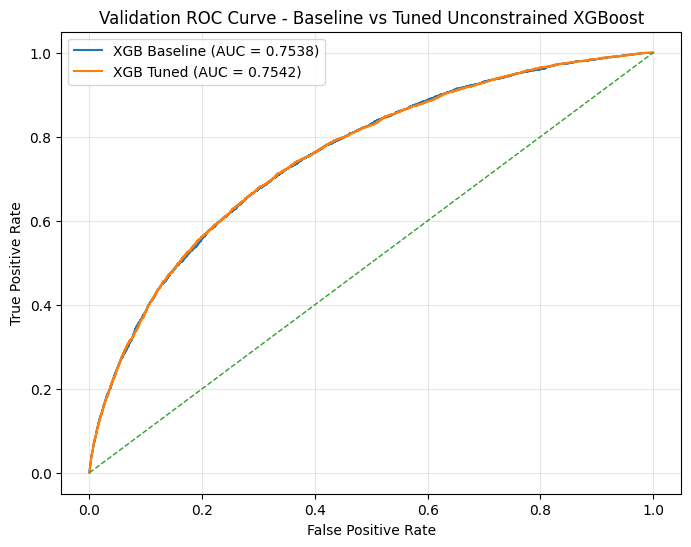

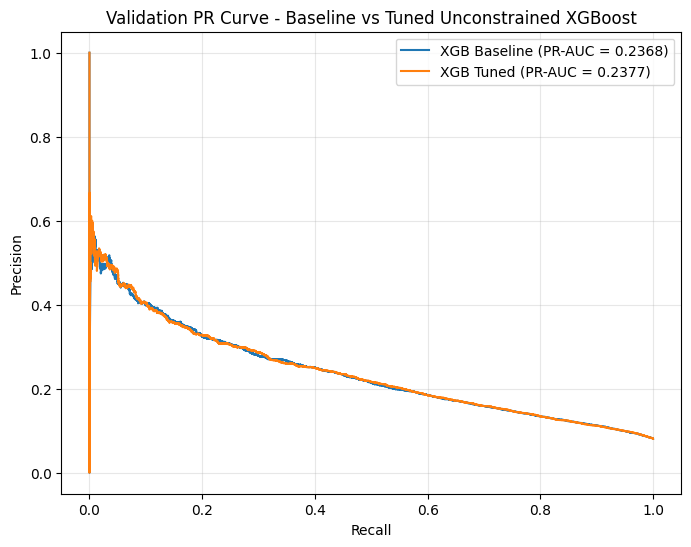

In [24]:

# Validation comparison plots: ROC & PR for baseline vs tuned unconstrained XGBoost

plot_roc_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob),
        "XGB Tuned": (y_val, tuned_val_prob)
    },
    title="Validation ROC Curve - Baseline vs Tuned Unconstrained XGBoost"
)

plot_pr_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob),
        "XGB Tuned": (y_val, tuned_val_prob)
    },
    title="Validation PR Curve - Baseline vs Tuned Unconstrained XGBoost"
)

In [25]:
# Display validation-only comparison table
display(validation_compare_df)

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration
0,xgb_unconstrained_baseline,validation,0.753768,0.236797,0.068078,0.376673,830
1,xgb_unconstrained_tuned,validation,0.754188,0.237661,0.068052,0.378648,829


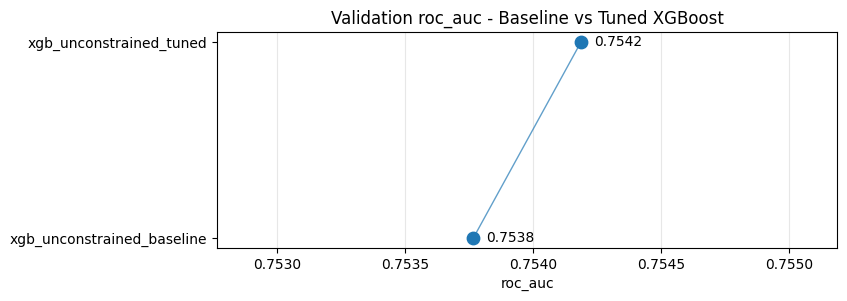

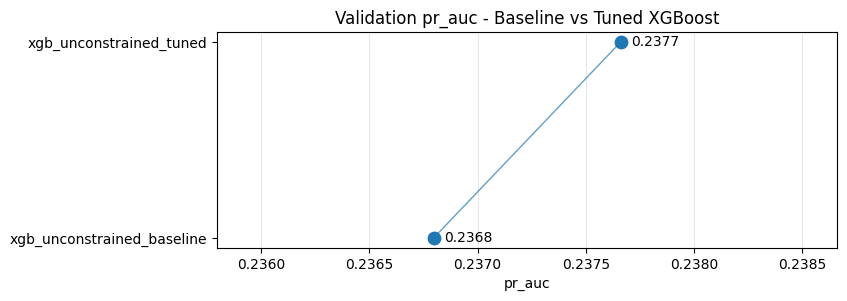

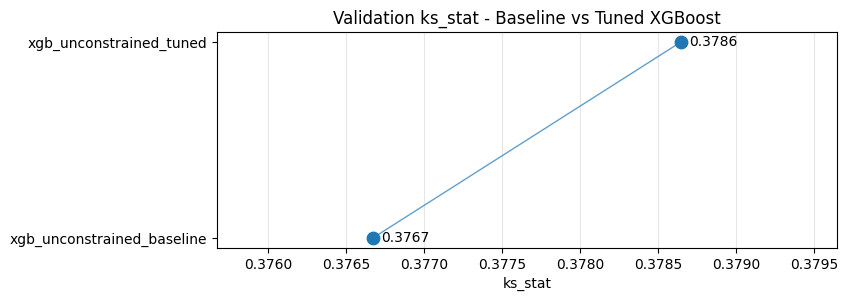

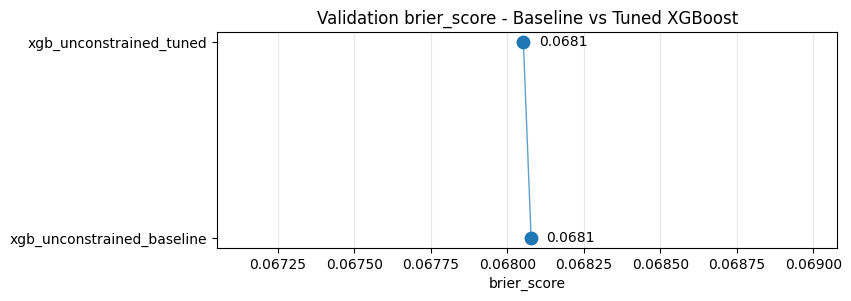

In [26]:

# Plot validation metric comparisons: baseline vs tuned unconstrained XGBoost

metrics_to_plot = ["roc_auc", "pr_auc", "ks_stat", "brier_score"]

for metric in metrics_to_plot:
    plot_two_model_comparison(
        compare_df=validation_compare_df,
        value_col=metric,
        title=f"Validation {metric} - Baseline vs Tuned XGBoost",
        x_label=metric,
        as_percent=False,
        decimals=4
    )

## CONSTRAINED XGBOOST MODEL

We introduce the following constraints on the XGBoost model:

1. Monotonicity on selected features whose economic direction is well understood  
2. Additivity so the model cannot learn cross-feature interaction effects


### MONOTONIC CONSTRAINTS

Specify monotonic directions for selected original features:
- +1 means higher feature values should increase predicted default risk
- -1 means higher feature values should decrease predicted default risk
- 0 means no monotonic constraint is imposed

NOTE: Direction determined at raw dataset feature level (vs after one-hot encoding) first, then mapped to encoded features for training

In [27]:

# Define monotonic directions for selected original features
# (NB To be mapped onto the one-hot encoded XGBoost features)

original_feature_monotonicity = {
    "AMT_INCOME_TOTAL": -1,                 # Higher income should not increase default risk
    "DAYS_BIRTH": -1,                       # Older age should not increase default risk
    "DAYS_EMPLOYED": -1,                    # Longer employment should not increase default risk
    "AMT_REQ_CREDIT_BUREAU_HOUR": 1,        # More bureau inquiries should not decrease risk
    "AMT_REQ_CREDIT_BUREAU_DAY": 1,
    "AMT_REQ_CREDIT_BUREAU_WEEK": 1,
    "AMT_REQ_CREDIT_BUREAU_MON": 1,
    "AMT_REQ_CREDIT_BUREAU_QRT": 1,
    "AMT_REQ_CREDIT_BUREAU_YEAR": 1,
    "EXT_SOURCE_1": -1,                     # Higher external scores should not increase risk
    "EXT_SOURCE_2": -1,
    "EXT_SOURCE_3": -1
}

original_feature_monotonicity

{'AMT_INCOME_TOTAL': -1,
 'DAYS_BIRTH': -1,
 'DAYS_EMPLOYED': -1,
 'AMT_REQ_CREDIT_BUREAU_HOUR': 1,
 'AMT_REQ_CREDIT_BUREAU_DAY': 1,
 'AMT_REQ_CREDIT_BUREAU_WEEK': 1,
 'AMT_REQ_CREDIT_BUREAU_MON': 1,
 'AMT_REQ_CREDIT_BUREAU_QRT': 1,
 'AMT_REQ_CREDIT_BUREAU_YEAR': 1,
 'EXT_SOURCE_1': -1,
 'EXT_SOURCE_2': -1,
 'EXT_SOURCE_3': -1}

In [28]:
# Build table of features for which we apply monotonic constraints

monotonic_feature_summary_df = pd.DataFrame({
    "feature_name": list(original_feature_monotonicity.keys()),
    "monotone_direction": list(original_feature_monotonicity.values())
})

# Add a plain-English interpretation column to display results later
monotonic_feature_summary_df["interpretation"] = monotonic_feature_summary_df["monotone_direction"].map({
    1: "Higher values should not decrease predicted risk",
    -1: "Higher values should not increase predicted risk"
})

monotonic_feature_summary_df

,feature_name,monotone_direction,interpretation
0,AMT_INCOME_TOTAL,-1,Higher values should not increase predicted risk
1,DAYS_BIRTH,-1,Higher values should not increase predicted risk
2,DAYS_EMPLOYED,-1,Higher values should not increase predicted risk
3,AMT_REQ_CREDIT_BUREAU_HOUR,1,Higher values should not decrease predicted risk
4,AMT_REQ_CREDIT_BUREAU_DAY,1,Higher values should not decrease predicted risk
5,AMT_REQ_CREDIT_BUREAU_WEEK,1,Higher values should not decrease predicted risk
6,AMT_REQ_CREDIT_BUREAU_MON,1,Higher values should not decrease predicted risk
7,AMT_REQ_CREDIT_BUREAU_QRT,1,Higher values should not decrease predicted risk
8,AMT_REQ_CREDIT_BUREAU_YEAR,1,Higher values should not decrease predicted risk
9,EXT_SOURCE_1,-1,Higher values should not increase predicted risk


##### Map monotonic directions onto the encoded training data

Since categorical variables were one-hot encoded downstream, we now build a monotone-constraint vector aligned with feature_names.

Only selected original numeric features receive non-zero monotonic constraints. All other encoded columns remain unconstrained.

In [29]:
# Build monotone-constraint list aligned with encoded training data

monotone_constraints_list = []

for feature in feature_names:
    # If encoded feature name exactly matches selected raw numeric features apply its monotonic direction
    if feature in original_feature_monotonicity:
        monotone_constraints_list.append(original_feature_monotonicity[feature])
    # Otherwise assign 0 meaning no monotonic constraint
    else:
        monotone_constraints_list.append(0)

# XGBoost accepts monotone constraints as a tuple
monotone_constraints_tuple = tuple(monotone_constraints_list)

print(f"Total encoded features: {len(feature_names)}")
print(f"Total monotone constraints: {len(monotone_constraints_tuple)}")
print(f"Non-zero monotone constraints: {sum(int(x != 0) for x in monotone_constraints_tuple)}")

Total encoded features: 127
Total monotone constraints: 127
Non-zero monotone constraints: 12


In [30]:
# Build diagnostic table showing which encoded columns received non-zero monotonic constraint

monotone_alignment_df = pd.DataFrame({
    "encoded_feature_name": feature_names,
    "monotone_direction": monotone_constraints_tuple
})

monotone_alignment_nonzero_df = monotone_alignment_df[
    monotone_alignment_df["monotone_direction"] != 0
].copy()

monotone_alignment_nonzero_df

,encoded_feature_name,monotone_direction
0,AMT_INCOME_TOTAL,-1
4,DAYS_BIRTH,-1
5,DAYS_EMPLOYED,-1
11,EXT_SOURCE_1,-1
12,EXT_SOURCE_2,-1
13,EXT_SOURCE_3,-1
14,AMT_REQ_CREDIT_BUREAU_HOUR,1
15,AMT_REQ_CREDIT_BUREAU_DAY,1
16,AMT_REQ_CREDIT_BUREAU_WEEK,1
17,AMT_REQ_CREDIT_BUREAU_MON,1


In [31]:
# Save the encoded-feature monotonic alignment table to output in csv

MONOTONE_ALIGNMENT_CSV = XGBOOST_OUTPUT_DIR / "xgb_monotone_constraint_alignment.csv"

monotone_alignment_nonzero_df.to_csv(MONOTONE_ALIGNMENT_CSV, index=False)

print(f"Saved: {MONOTONE_ALIGNMENT_CSV}")

Saved: ../output/xgboost/xgb_monotone_constraint_alignment.csv


### ADDITIVITY CONSTRAINTS

Additivity enforced using interaction constraints to prevent trees from learning cross-feature interactions

Each encoded feature column is assigned to its own singleton interaction group blocking interaction paths that combine multiple features

In [32]:

# Build singleton interaction-constraint groups to enforce additivity.
# - trees may learn nonlinear effects within a single feature
# - trees may not combine multiple features along the same path

interaction_constraints_list = [[feature] for feature in feature_names]

print(f"Number of singleton interaction groups: {len(interaction_constraints_list)}")
print("First 5 groups:", interaction_constraints_list[:5])

Number of singleton interaction groups: 127
First 5 groups: [['AMT_INCOME_TOTAL'], ['AMT_CREDIT'], ['AMT_ANNUITY'], ['AMT_GOODS_PRICE'], ['DAYS_BIRTH']]


In [33]:

# Sanity check: every constrained feature name should be present in the encoded training data cols

all_constraint_features = [group[0] for group in interaction_constraints_list]

missing_constraint_features = [
    feature for feature in all_constraint_features
    if feature not in X_train_ready.columns
]

print(f"Total interaction-constraint features: {len(all_constraint_features)}")
print(f"Missing from training matrix: {len(missing_constraint_features)}")

if missing_constraint_features:
    print("Missing features:", missing_constraint_features[:10])
else:
    print("All interaction-constraint feature names are present in X_train_ready.")

Total interaction-constraint features: 127
Missing from training matrix: 0
All interaction-constraint feature names are present in X_train_ready.


### TRAIN CONSTRAINED XGBOOST 

NOTE: To keep the comparison focused on the effect of the structural constraints, we start from the selected tuned unconstrained hyperparameter configuration and then add:

- monotonicity constraints on selected features  
- interaction constraints to enforce additivity

I.e. We use the same hyperparameter values that were optimal for the UNconstrained model, no hyperparameter tuning specifically for this constrained model at this point

In [35]:
xgb_constrained = XGBClassifier(
    objective="binary:logistic",    # Setting goal as binary pred
    eval_metric="aucpr",            # PR-AUC as primary eval metric given class imbalance (others computed with helpers outside)
    n_estimators=1000,              # Max no. of trees wide (sequential boosting rounds) (set high to likely let early stopping control actual num)
    early_stopping_rounds=50,       # Stop early after n rounds if validation metric doesn't improve
    learning_rate=0.05,             # Scaling factor applied to each new tree's contribution to the final prediction (step size)
    max_depth=4,                    # Max no. of trees deep (set low for xgboost - focus on sequential improvement ie estimators vs deep complexity)
    min_child_weight=5,             # Only create new branch big enough group of samples
    subsample=0.8,                  # Fraction of sample rows sampled for each boosting round (adds regularization / reduces overfitting)
    colsample_bytree=0.8,           # Fraction of features sampled when building each tree (also adds regularization / reduces overfitting)
    reg_lambda=1.0,                 # L2 regularization strength on leaf weights (higher = more shrinkage / less overfitting)
    tree_method="hist",             # Use histogram-based tree construction (faster / more efficient for large tabular datasets)
    device="cuda",                  # Use GPU
    random_state=42,                # Seed for reproducibility
    n_jobs=-1,                       # Use all available CPU threads (inly for CPU-side work (per above gpu used in paralalizable training))
    monotone_constraints=monotone_constraints_tuple,                   # Enforce monotonic directions on selected features
    interaction_constraints=interaction_constraints_list,              # Enforce additivity by blocking cross-feature interactions
)

# Fit constrained model using validation data split for early stopping
xgb_constrained.fit(
    X_train_ready,
    y_train,
    eval_set=[(X_val_ready, y_val)],
    verbose=False
)

print(f"Constrained best iteration: {xgb_constrained.best_iteration}")
print(f"Constrained best score: {xgb_constrained.best_score}")

Constrained best iteration: 999
Constrained best score: 0.21592581946248662


In [36]:
# Evaluate constrained XGBoost on the validation data split only

constrained_val_result = evaluate_binary_model(
    model=xgb_constrained,
    X=X_val_ready,
    y=y_val,
    split_name="validation",
    model_name="xgb_constrained"
)

# Store validation predicted probabilities for comparison plots
constrained_val_prob = xgb_constrained.predict_proba(X_val_ready)[:, 1]

# Build validation comparison between tuned unconstrained and constrained
xgb_constraint_compare_df = pd.DataFrame([
    tuned_val_result,
    constrained_val_result
])

# Add metadata for later cross-architecture comparison
xgb_constraint_compare_df["architecture"] = "xgboost"
xgb_constraint_compare_df["experiment_group"] = "constrained_vs_unconstrained"
xgb_constraint_compare_df["constraint_status"] = xgb_constraint_compare_df["model_name"].map({
    "xgb_unconstrained_tuned": "unconstrained",
    "xgb_constrained": "constrained"
})

xgb_constraint_compare_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,architecture,experiment_group,constraint_status
0,xgb_unconstrained_tuned,validation,0.754188,0.237661,0.068052,0.378648,829,xgboost,constrained_vs_unconstrained,unconstrained
1,xgb_constrained,validation,0.744234,0.216219,0.069027,0.363935,999,xgboost,constrained_vs_unconstrained,constrained


In [37]:
# Save constrained-model validation outputs for analysis later

CONSTRAINED_VAL_RESULTS_CSV = XGBOOST_OUTPUT_DIR / "xgb_constrained_validation_results.csv"
CONSTRAINED_COMPARE_CSV = XGBOOST_OUTPUT_DIR / "xgb_constrained_vs_unconstrained_validation_comparison.csv"

# Save single-row constrained validation result
pd.DataFrame([constrained_val_result]).to_csv(CONSTRAINED_VAL_RESULTS_CSV, index=False)

# Save tuned unconstrained vs constrained validation comparison
xgb_constraint_compare_df.to_csv(CONSTRAINED_COMPARE_CSV, index=False)

print(f"Saved: {CONSTRAINED_VAL_RESULTS_CSV}")
print(f"Saved: {CONSTRAINED_COMPARE_CSV}")

Saved: ../output/xgboost/xgb_constrained_validation_results.csv
Saved: ../output/xgboost/xgb_constrained_vs_unconstrained_validation_comparison.csv


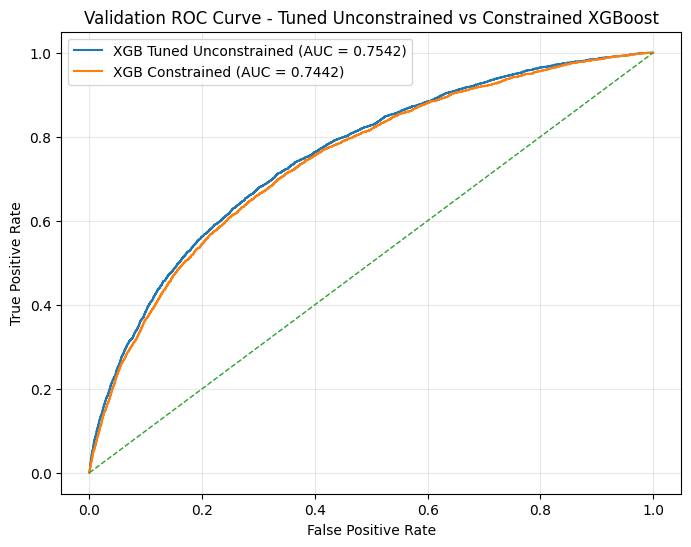

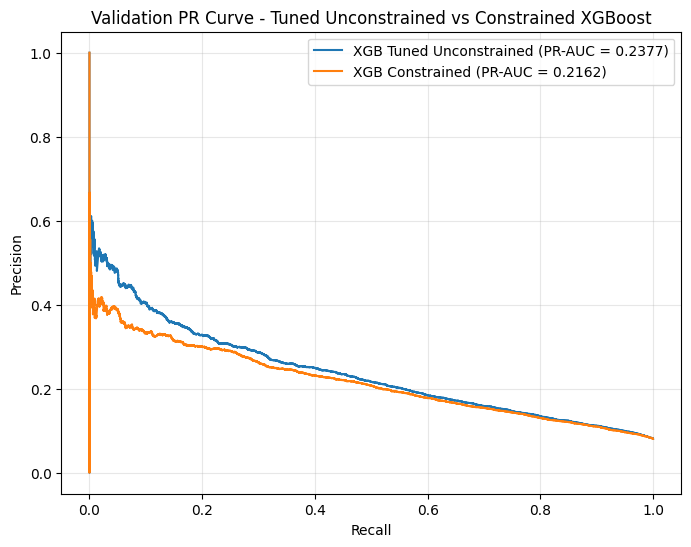

In [38]:
# Validation ROC and PR curves: # tuned unconstrained vs constrained XGBoost

plot_roc_curves(
    curves_dict={
        "XGB Tuned Unconstrained": (y_val, tuned_val_prob),
        "XGB Constrained": (y_val, constrained_val_prob)
    },
    title="Validation ROC Curve - Tuned Unconstrained vs Constrained XGBoost"
)

plot_pr_curves(
    curves_dict={
        "XGB Tuned Unconstrained": (y_val, tuned_val_prob),
        "XGB Constrained": (y_val, constrained_val_prob)
    },
    title="Validation PR Curve - Tuned Unconstrained vs Constrained XGBoost"
)

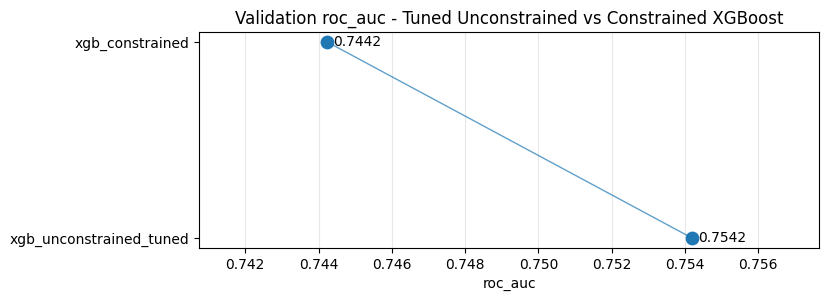

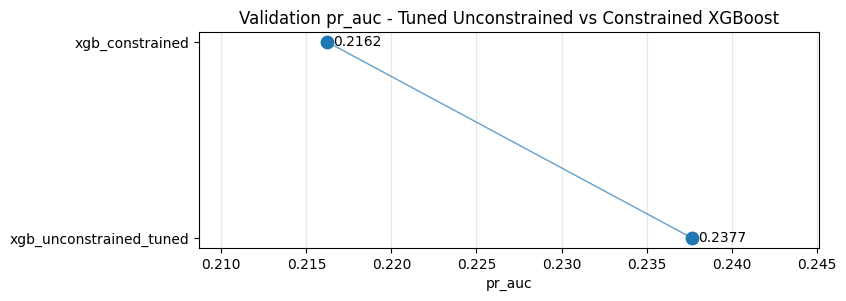

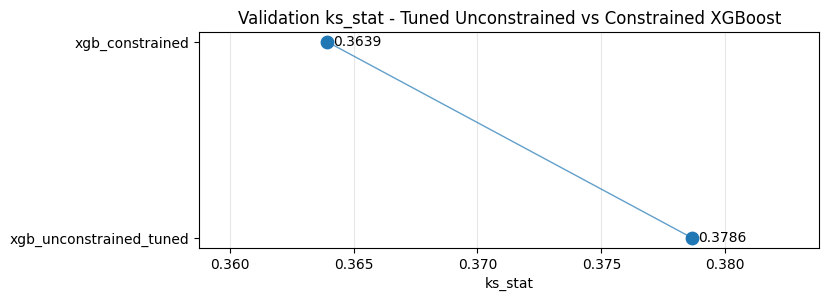

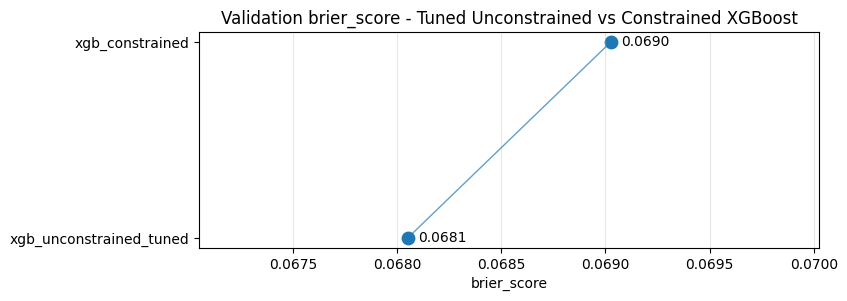

In [39]:
# Plot validation metric comparisons: # tuned unconstrained vs constrained XGBoost
metrics_to_plot = ["roc_auc", "pr_auc", "ks_stat", "brier_score"]

for metric in metrics_to_plot:
    plot_two_model_comparison(
        compare_df=xgb_constraint_compare_df,
        value_col=metric,
        title=f"Validation {metric} - Tuned Unconstrained vs Constrained XGBoost",
        x_label=metric,
        as_percent=False,
        decimals=4
    )

### Validation Results: Constrained XGBoost 

This experiment compares the locked tuned unconstrained XGBoost benchmark against the constrained XGBoost model that imposes both monotonicity and additivity.

Key observations:

- Validation PR-AUC decreased from **0.237661** in the tuned unconstrained model to **0.216331** in the constrained model.
- Validation ROC-AUC decreased from **0.754188** to **0.744080**.
- Validation KS decreased from **0.378648** to **0.364196**.
- Validation Brier score increased from **0.068052** to **0.069027** (higher is worse).

Interpretation:

- The constrained XGBoost model underperformed the tuned unconstrained benchmark across all four validation metrics. This suggests that imposing the selected structural constraints reduced predictive flexibility in a measurable way.
- Because the dataset, feature set, train/validation data splits, and baseline hyperparameter regime were held fixed, this performance gap is interpretable primarily as the validation-based cost of the selected structural constraints under this training and evaluation setup.
- The largest relative deterioration appears in PR-AUC, which is especially important in this project because default is the minority class. This suggests that the constrained model loses some ability to identify high-risk default cases under class imbalance.
- The constrained model also trained all the way to the maximum n_estimators limit (best_iteration = 999), whereas the tuned unconstrained model stopped earlier (best_iteration = 829). This suggests the constrained model may need more boosting rounds to approach its best attainable fit under the imposed structural restrictions, or that the constraints materially reduced the model's ability to improve validation performance.
- Overall, these results support the project hypothesis that compliance-oriented structural restrictions can improve interpretability and governance alignment, but at a cost in predictive performance.

NOTE: A limitation of this comparison is that the constrained model was evaluated under the same fixed validation-split design used elsewhere in the notebook, so the magnitude of the gap should be interpreted as the estimated cost of constraints under this evaluation setup rather than as a universally exact measure.

## FINAL TEST EVALUATION AND BUSINESS-LEVEL INTERPRETATION

Now that the unconstrained and constrained XGBoost model specifications are locked, we evaluate both on the held-out test data split.

In addition to standard model metrics, we translate the final test comparison into two business-facing views:

1. **Approval rate at fixed observed bad rate**
   - If the lender wants to maintain the same observed default rate among approved borrowers, how much approval volume can each model support?

2. **Additional defaults approved per 10,000 applications at fixed approval rate**
   - If the lender wants to maintain the same approval volume, how much more credit risk is admitted under the weaker model?

NB Not new training objectives. Meant to provide a more real-world measure of the impact of regulatory constraints.

In [40]:
# Evaluate the final tuned unconstrained and constrained XGBoost models on the held-out test data split

# Evaluate tuned unconstrained XGBoost on test
tuned_test_result = evaluate_binary_model(
    model=best_xgb_unconstrained,
    X=X_test_ready,
    y=y_test,
    split_name="test",
    model_name="xgb_unconstrained_tuned"
)

# Evaluate constrained XGBoost on test
constrained_test_result = evaluate_binary_model(
    model=xgb_constrained,
    X=X_test_ready,
    y=y_test,
    split_name="test",
    model_name="xgb_constrained"
)

# Store predicted default probabilities for later business analysis
tuned_test_prob = best_xgb_unconstrained.predict_proba(X_test_ready)[:, 1]
constrained_test_prob = xgb_constrained.predict_proba(X_test_ready)[:, 1]

# Build a compact final XGBoost test comparison table
xgb_test_compare_df = pd.DataFrame([
    tuned_test_result,
    constrained_test_result
])

# Add metadata for later project-wide comparison across architectures
xgb_test_compare_df["architecture"] = "xgboost"
xgb_test_compare_df["experiment_group"] = "constrained_vs_unconstrained_test"
xgb_test_compare_df["constraint_status"] = xgb_test_compare_df["model_name"].map({
    "xgb_unconstrained_tuned": "unconstrained",
    "xgb_constrained": "constrained"
})

xgb_test_compare_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,architecture,experiment_group,constraint_status
0,xgb_unconstrained_tuned,test,0.752627,0.233482,0.068262,0.376523,829,xgboost,constrained_vs_unconstrained_test,unconstrained
1,xgb_constrained,test,0.743304,0.220431,0.068903,0.367705,999,xgboost,constrained_vs_unconstrained_test,constrained


In [41]:
# Save final XGBoost test comparison outputs for this notebook.

# Define file paths for final XGBoost test results
XGB_TEST_COMPARE_CSV = XGBOOST_OUTPUT_DIR / "xgb_constrained_vs_unconstrained_test_comparison.csv"

# Save XGBoost-specific test comparison
xgb_test_compare_df.to_csv(XGB_TEST_COMPARE_CSV, index=False)

print(f"Saved: {XGB_TEST_COMPARE_CSV}")

Saved: ../output/xgboost/xgb_constrained_vs_unconstrained_test_comparison.csv


### Interpretation of final XGBoost test results

The final held-out test comparison confirms the same pattern observed on the validation split: the constrained XGBoost model underperforms the tuned unconstrained benchmark across all four evaluation metrics.

Key observations:

- Test PR-AUC decreased from **0.233482** to **0.220491**.
- Test ROC-AUC decreased from **0.752627** to **0.743096**.
- Test KS decreased from **0.376523** to **0.368952**.
- Test Brier score increased from **0.068262** to **0.068904** (higher is worse).

Interpretation:

- Because the constrained and unconstrained models were trained on the same dataset and feature set, and differ primarily in the imposition of monotonicity and additivity, this test-set performance gap is interpretable primarily as the held-out predictive cost of the selected compliance-style structural constraints under this training and evaluation setup.
- The fact that the same directional deterioration appears on both validation and test strengthens confidence that the result is not just a validation-split artifact.
- The largest practical concern remains the drop in PR-AUC, since this metric is especially important for imbalanced default prediction and is most closely related to how well the model isolates high-risk borrowers.

In [42]:
# Helper func to compute approval (no default pred) and risk outcomes for a model at a chosen NPL (bad rate target) / approval rate goal
# Supports two operating-point modes:
# 1. fixed approval rate
# 2. fixed observed bad-rate target

def evaluate_operating_point(y_true, y_score, approval_rate=None, bad_rate_target=None):

    # Convert inputs to numpy arrays for easier indexing
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # Sort applicants from safest to riskiest according to predicted (lower score = safer applicant)
    order = np.argsort(y_score)

    sorted_y_true = y_true[order]
    sorted_y_score = y_score[order]

    n_obs = len(sorted_y_true)


    # Case 1: fixed approval rate

    if approval_rate is not None and bad_rate_target is None:

        # Compute the exact number of applicants to approve
        n_approve = int(np.floor(approval_rate * n_obs))

        # Guard against edge cases
        n_approve = max(1, min(n_approve, n_obs))


    # Case 2: fixed observed bad rate target

    elif bad_rate_target is not None and approval_rate is None:

        # Compute cumulative defaults among the safest applicants
        cumulative_defaults = np.cumsum(sorted_y_true)

        # Candidate approval counts from 1 up to all applicants
        candidate_counts = np.arange(1, n_obs + 1)

        # Observed cumulative bad rate among approved applicants at
        # each possible approval count
        cumulative_bad_rates = cumulative_defaults / candidate_counts

        # Find all approval counts that satisfy the target bad rate
        feasible_counts = candidate_counts[cumulative_bad_rates <= bad_rate_target]

        # If nothing satisfies the target, approve the single safest
        # applicant as the most conservative fallback
        if len(feasible_counts) == 0:
            n_approve = 1
        else:
            # Choose the largest feasible approval count so approval
            # volume is maximized subject to the bad rate constraint
            n_approve = int(feasible_counts[-1])

    else:
        raise ValueError("Set exactly one of approval_rate or bad_rate_target.")

    # Split approved vs rejected populations
    approved_y_true = sorted_y_true[:n_approve]
    approved_y_score = sorted_y_score[:n_approve]

    rejected_y_true = sorted_y_true[n_approve:]

    # Compute decision-level outcomes
    approved_defaults = int(approved_y_true.sum())
    approved_nondefaults = int(len(approved_y_true) - approved_defaults)

    rejected_defaults = int(rejected_y_true.sum())
    rejected_nondefaults = int(len(rejected_y_true) - rejected_defaults)

    observed_bad_rate_among_approved = approved_defaults / len(approved_y_true)
    realized_approval_rate = len(approved_y_true) / n_obs

    # Store highest predicted default probability still included in the approved population
    approval_threshold = approved_y_score[-1]

    return {
        "n_total_applicants": n_obs,
        "n_approved": len(approved_y_true),
        "n_rejected": len(rejected_y_true),
        "approval_rate": realized_approval_rate,
        "approved_defaults": approved_defaults,
        "approved_nondefaults": approved_nondefaults,
        "rejected_defaults": rejected_defaults,
        "rejected_nondefaults": rejected_nondefaults,
        "observed_bad_rate_among_approved": observed_bad_rate_among_approved,
        "approval_threshold": approval_threshold
    }

### Business view 1: additional defaults approved per 10,000 applications at fixed approval rate

Simulates business setting where lender wants to maintain same loan throughput and asks how credit quality changes under the constrained model

In [43]:
# -------------------------------------------------------------------
# Compare the two XGBoost models at the same approval rate.
# - both models approve the same share of the portfolio
# - any difference in approved defaults reflects weaker or stronger risk separation at that same business volume
# -------------------------------------------------------------------

# Set target approval rate for the comparison
FIXED_APPROVAL_RATE = 0.70

# Evaluate both models at the same approval rate
tuned_fixed_approval = evaluate_operating_point(
    y_true=y_test,
    y_score=tuned_test_prob,
    approval_rate=FIXED_APPROVAL_RATE
)

constrained_fixed_approval = evaluate_operating_point(
    y_true=y_test,
    y_score=constrained_test_prob,
    approval_rate=FIXED_APPROVAL_RATE
)

# Build comparison table
fixed_approval_compare_df = pd.DataFrame([
    {"model_name": "xgb_unconstrained_tuned", **tuned_fixed_approval},
    {"model_name": "xgb_constrained", **constrained_fixed_approval}
])


# Store extra defaults approved by constrained model per 10,000 applicants at the same approval rate
defaults_diff = (
    constrained_fixed_approval["approved_defaults"]
    - tuned_fixed_approval["approved_defaults"]
)

per_10000_scale = 10000 / len(y_test)

fixed_approval_compare_df["scenario"] = f"fixed_approval_rate_{int(FIXED_APPROVAL_RATE * 100)}pct"

print(f"Extra defaults approved by constrained model at fixed approval rate: {defaults_diff}")
print(f"Extra defaults per 10,000 applicants: {defaults_diff * per_10000_scale:.2f}")

fixed_approval_compare_df

Extra defaults approved by constrained model at fixed approval rate: 44
Extra defaults per 10,000 applicants: 9.54


,model_name,n_total_applicants,n_approved,n_rejected,approval_rate,approved_defaults,approved_nondefaults,rejected_defaults,rejected_nondefaults,observed_bad_rate_among_approved,approval_threshold,scenario
0,xgb_unconstrained_tuned,46101,32270,13831,0.699985,1321,30949,2400,11431,0.040936,0.088263,fixed_approval_rate_70pct
1,xgb_constrained,46101,32270,13831,0.699985,1365,30905,2356,11475,0.042299,0.087815,fixed_approval_rate_70pct


In [44]:
# Save fixed approval rate business comparison outputs

FIXED_APPROVAL_COMPARE_CSV = XGBOOST_OUTPUT_DIR / "xgb_business_fixed_approval_rate_comparison.csv"

fixed_approval_compare_df.to_csv(FIXED_APPROVAL_COMPARE_CSV, index=False)

print(f"Saved: {FIXED_APPROVAL_COMPARE_CSV}")

Saved: ../output/xgboost/xgb_business_fixed_approval_rate_comparison.csv


### Business view 2: approval rate at fixed observed bad rate

We hold credit quality constant and ask how much approval volume each model can support. Simulates a lender that wants to maintain the same observed default rate among approved borrowers.

In [45]:
# Compare the two XGBoost models at the same observed bad-rate target
# - both models are asked to maintain the same portfolio quality
# - any difference in approval rate shows the business-volume cost of using a regulated model

# Set target observed bad rate among approved applicants
FIXED_BAD_RATE_TARGET = 0.08

# Evaluate both models at the same observed bad-rate target
tuned_fixed_bad_rate = evaluate_operating_point(
    y_true=y_test,
    y_score=tuned_test_prob,
    bad_rate_target=FIXED_BAD_RATE_TARGET
)

constrained_fixed_bad_rate = evaluate_operating_point(
    y_true=y_test,
    y_score=constrained_test_prob,
    bad_rate_target=FIXED_BAD_RATE_TARGET
)

# Build comparison table
fixed_bad_rate_compare_df = pd.DataFrame([
    {"model_name": "xgb_unconstrained_tuned", **tuned_fixed_bad_rate},
    {"model_name": "xgb_constrained", **constrained_fixed_bad_rate}
])

fixed_bad_rate_compare_df["scenario"] = f"fixed_bad_rate_target_{int(FIXED_BAD_RATE_TARGET * 100)}pct"

# Compute approval-rate loss under the constrained model
approval_rate_diff = (
    tuned_fixed_bad_rate["approval_rate"]
    - constrained_fixed_bad_rate["approval_rate"]
)

print(f"Approval-rate loss under constrained model: {approval_rate_diff:.4f}")
print(f"Approval-rate loss in percentage points: {approval_rate_diff * 100:.2f}")

fixed_bad_rate_compare_df

Approval-rate loss under constrained model: 0.0004
Approval-rate loss in percentage points: 0.04


,model_name,n_total_applicants,n_approved,n_rejected,approval_rate,approved_defaults,approved_nondefaults,rejected_defaults,rejected_nondefaults,observed_bad_rate_among_approved,approval_threshold,scenario
0,xgb_unconstrained_tuned,46101,46040,61,0.998677,3683,42357,38,23,0.079996,0.564002,fixed_bad_rate_target_8pct
1,xgb_constrained,46101,46023,78,0.998308,3681,42342,40,38,0.079982,0.517797,fixed_bad_rate_target_8pct


In [46]:
# Save fixed-bad-rate business comparison outputs.

FIXED_BAD_RATE_COMPARE_CSV = XGBOOST_OUTPUT_DIR / "xgb_business_fixed_bad_rate_comparison.csv"

fixed_bad_rate_compare_df.to_csv(FIXED_BAD_RATE_COMPARE_CSV, index=False)

print(f"Saved: {FIXED_BAD_RATE_COMPARE_CSV}")

Saved: ../output/xgboost/xgb_business_fixed_bad_rate_comparison.csv


### Sensitivity analysis for fixed bad-rate targets

The initial fixed-bad-rate analysis used an 8% observed bad-rate target among approved applicants. In practice, this target proved too loose, producing approval rates close to 100% for both models and therefore providing limited discrimination between them.

To obtain a more informative business comparison, we now run a sensitivity analysis at tighter observed bad-rate targets of 6%, 5%, and 4%.

We retain the original 8% result for transparency, but use the tighter targets to better understand how the constrained-versus-unconstrained gap behaves under more selective lending conditions.

In [47]:
# Helper func to compare tuned unconstrained vs constrained XGBoost at one fixed observed bad-rate target.

def compare_models_at_fixed_bad_rate_target(
    y_true,
    tuned_scores,
    constrained_scores,
    bad_rate_target
):

    # Evaluate tuned unconstrained model at the target bad rate
    tuned_result = evaluate_operating_point(
        y_true=y_true,
        y_score=tuned_scores,
        bad_rate_target=bad_rate_target
    )

    # Evaluate constrained model at the same target bad rate
    constrained_result = evaluate_operating_point(
        y_true=y_true,
        y_score=constrained_scores,
        bad_rate_target=bad_rate_target
    )

    # Build comparison table
    comparison_df = pd.DataFrame([
        {"model_name": "xgb_unconstrained_tuned", **tuned_result},
        {"model_name": "xgb_constrained", **constrained_result}
    ])

    # Label the operating-point scenario for traceability
    comparison_df["scenario"] = f"fixed_bad_rate_target_{int(bad_rate_target * 100)}pct"

    return comparison_df

In [48]:
# Run fixed-bad-rate sensitivity analysis at multiple tighter targets.
# 8% as the original reference point and add 6%, 5%, and 4%

# Define bad-rate targets to compare
bad_rate_targets_to_test = [0.08, 0.06, 0.05, 0.04]

# Store each two-row comparison table in a dictionary
fixed_bad_rate_sensitivity_results = {}

# Also build one stacked dataframe for easy display and saving
fixed_bad_rate_sensitivity_df_list = []

for target in bad_rate_targets_to_test:
    comparison_df = compare_models_at_fixed_bad_rate_target(
        y_true=y_test,
        tuned_scores=tuned_test_prob,
        constrained_scores=constrained_test_prob,
        bad_rate_target=target
    )

    fixed_bad_rate_sensitivity_results[target] = comparison_df
    fixed_bad_rate_sensitivity_df_list.append(comparison_df)

# Stack all scenarios into one long table
fixed_bad_rate_sensitivity_df = pd.concat(
    fixed_bad_rate_sensitivity_df_list,
    ignore_index=True
)

# Display the full sensitivity table
fixed_bad_rate_sensitivity_df

,model_name,n_total_applicants,n_approved,n_rejected,approval_rate,approved_defaults,approved_nondefaults,rejected_defaults,rejected_nondefaults,observed_bad_rate_among_approved,approval_threshold,scenario
0,xgb_unconstrained_tuned,46101,46040,61,0.998677,3683,42357,38,23,0.079996,0.564002,fixed_bad_rate_target_8pct
1,xgb_constrained,46101,46023,78,0.998308,3681,42342,40,38,0.079982,0.517797,fixed_bad_rate_target_8pct
2,xgb_unconstrained_tuned,46101,41195,4906,0.893581,2471,38724,1250,3656,0.059983,0.171975,fixed_bad_rate_target_6pct
3,xgb_constrained,46101,40950,5151,0.888267,2457,38493,1264,3887,0.060000,0.161523,fixed_bad_rate_target_6pct
4,xgb_unconstrained_tuned,46101,37309,8792,0.809288,1865,35444,1856,6936,0.049988,0.122690,fixed_bad_rate_target_5pct
5,xgb_constrained,46101,36740,9361,0.796946,1837,34903,1884,7477,0.050000,0.115550,fixed_bad_rate_target_5pct
6,xgb_unconstrained_tuned,46101,31467,14634,0.682567,1258,30209,2463,12171,0.039978,0.084256,fixed_bad_rate_target_4pct
7,xgb_constrained,46101,30783,15318,0.667730,1231,29552,2490,12828,0.039990,0.081170,fixed_bad_rate_target_4pct


In [49]:
# Save the full fixed-bad-rate sensitivity analysis.

FIXED_BAD_RATE_SENSITIVITY_CSV = XGBOOST_OUTPUT_DIR / "xgb_business_fixed_bad_rate_sensitivity.csv"

fixed_bad_rate_sensitivity_df.to_csv(FIXED_BAD_RATE_SENSITIVITY_CSV, index=False)

print(f"Saved: {FIXED_BAD_RATE_SENSITIVITY_CSV}")

Saved: ../output/xgboost/xgb_business_fixed_bad_rate_sensitivity.csv


In [50]:
# Build a compact summary of the fixed-bad-rate sensitivity results.
# Helps choose a headline bad target setting


fixed_bad_rate_summary_rows = []

for target, comparison_df in fixed_bad_rate_sensitivity_results.items():
    unconstrained_row = comparison_df[
        comparison_df["model_name"] == "xgb_unconstrained_tuned"
    ].iloc[0]

    constrained_row = comparison_df[
        comparison_df["model_name"] == "xgb_constrained"
    ].iloc[0]

    fixed_bad_rate_summary_rows.append({
        "bad_rate_target": target,
        "unconstrained_approval_rate": unconstrained_row["approval_rate"],
        "constrained_approval_rate": constrained_row["approval_rate"],
        "approval_rate_gap": unconstrained_row["approval_rate"] - constrained_row["approval_rate"]
    })

fixed_bad_rate_sensitivity_summary_df = pd.DataFrame(fixed_bad_rate_summary_rows)

fixed_bad_rate_sensitivity_summary_df

,bad_rate_target,unconstrained_approval_rate,constrained_approval_rate,approval_rate_gap
0,0.08,0.998677,0.998308,0.000369
1,0.06,0.893581,0.888267,0.005314
2,0.05,0.809288,0.796946,0.012342
3,0.04,0.682567,0.667730,0.014837


### Interpretation of fixed bad-rate sensitivity analysis

The fixed-bad-rate sensitivity analysis shows that the approval-rate gap between the constrained and unconstrained models becomes more visible as the target bad rate becomes more stringent.

- At **8%**, the gap is negligible because both models approve almost the entire portfolio.
- At **6%**, the gap becomes visible but remains modest.
- At **5%** and **4%**, the approval-rate gap becomes materially larger and stabilizes at roughly **1.22 percentage points**.

This pattern is intuitive: tighter portfolio-quality targets place more weight on fine-grained ranking performance, so the cost of the constrained model becomes more apparent under more selective lending conditions. We use **5%** as the headline operating point because it produces a clear and decision-relevant gap without moving to an excessively restrictive threshold.

In [51]:
# Select headline bad-rate target for the compact business summary
# NB Full sensitivity analysis saved separately

# Update this after reviewing the summary table above
SELECTED_BAD_RATE_TARGET = 0.05

selected_fixed_bad_rate_compare_df = fixed_bad_rate_sensitivity_results[SELECTED_BAD_RATE_TARGET].copy()

print(f"Selected headline bad-rate target: {SELECTED_BAD_RATE_TARGET:.0%}")
selected_fixed_bad_rate_compare_df

Selected headline bad-rate target: 5%


,model_name,n_total_applicants,n_approved,n_rejected,approval_rate,approved_defaults,approved_nondefaults,rejected_defaults,rejected_nondefaults,observed_bad_rate_among_approved,approval_threshold,scenario
0,xgb_unconstrained_tuned,46101,37309,8792,0.809288,1865,35444,1856,6936,0.049988,0.12269,fixed_bad_rate_target_5pct
1,xgb_constrained,46101,36740,9361,0.796946,1837,34903,1884,7477,0.050000,0.11555,fixed_bad_rate_target_5pct


In [52]:
# Save the selected headline fixed-bad-rate comparison

FIXED_BAD_RATE_COMPARE_CSV = XGBOOST_OUTPUT_DIR / "xgb_business_fixed_bad_rate_comparison.csv"

selected_fixed_bad_rate_compare_df.to_csv(FIXED_BAD_RATE_COMPARE_CSV, index=False)

print(f"Saved updated headline fixed-bad-rate comparison: {FIXED_BAD_RATE_COMPARE_CSV}")

Saved updated headline fixed-bad-rate comparison: ../output/xgboost/xgb_business_fixed_bad_rate_comparison.csv


In [53]:
# Rebuild the compact business summary table using:
# - existing fixed approval-rate result
# - selected headline fixed bad-rate result from the sensitivity analysis

# Pull approval rates from the selected fixed-bad-rate comparison
selected_unconstrained_approval_rate = selected_fixed_bad_rate_compare_df.loc[
    selected_fixed_bad_rate_compare_df["model_name"] == "xgb_unconstrained_tuned",
    "approval_rate"
].iloc[0]

selected_constrained_approval_rate = selected_fixed_bad_rate_compare_df.loc[
    selected_fixed_bad_rate_compare_df["model_name"] == "xgb_constrained",
    "approval_rate"
].iloc[0]

# Compute approval-rate loss under the constrained model
selected_approval_rate_diff = (
    selected_unconstrained_approval_rate - selected_constrained_approval_rate
)

# Rebuild compact business summary table
xgb_business_summary_df = pd.DataFrame([
    {
        "comparison_type": "fixed_approval_rate",
        "operating_point": FIXED_APPROVAL_RATE,
        "unconstrained_approved_defaults": tuned_fixed_approval["approved_defaults"],
        "constrained_approved_defaults": constrained_fixed_approval["approved_defaults"],
        "extra_defaults_constrained": defaults_diff,
        "extra_defaults_per_10000": defaults_diff * per_10000_scale
    },
    {
        "comparison_type": "fixed_bad_rate_target",
        "operating_point": SELECTED_BAD_RATE_TARGET,
        "unconstrained_approval_rate": selected_unconstrained_approval_rate,
        "constrained_approval_rate": selected_constrained_approval_rate,
        "approval_rate_loss": selected_approval_rate_diff,
        "approval_rate_loss_pct_points": selected_approval_rate_diff * 100
    }
])

xgb_business_summary_df

,comparison_type,operating_point,unconstrained_approved_defaults,constrained_approved_defaults,extra_defaults_constrained,extra_defaults_per_10000,unconstrained_approval_rate,constrained_approval_rate,approval_rate_loss,approval_rate_loss_pct_points
0,fixed_approval_rate,0.70,1321.0,1365.0,44.0,9.544262,NaN,NaN,NaN,NaN
1,fixed_bad_rate_target,0.05,NaN,NaN,NaN,NaN,0.809288,0.796946,0.012342,1.234247


In [54]:
# Add a compact display table with explicit business deltas.

xgb_business_delta_display_df = pd.DataFrame([
    {
        "scenario": "Fixed 70% approval rate",
        "unconstrained": tuned_fixed_approval["approved_defaults"],
        "constrained": constrained_fixed_approval["approved_defaults"],
        "gap": defaults_diff,
        "interpretation": "More defaults approved under constrained model"
    },
    {
        "scenario": f"Fixed {SELECTED_BAD_RATE_TARGET:.0%} bad-rate target",
        "unconstrained": selected_unconstrained_approval_rate * 100,
        "constrained": selected_constrained_approval_rate * 100,
        "gap": selected_approval_rate_diff * 100,
        "interpretation": "Approval-rate loss under constrained model"
    }
])

xgb_business_delta_display_df

,scenario,unconstrained,constrained,gap,interpretation
0,Fixed 70% approval rate,1321.00000,1365.000000,44.000000,More defaults approved under constrained model
1,Fixed 5% bad-rate target,80.92883,79.694584,1.234247,Approval-rate loss under constrained model


In [55]:
# Save the updated compact business summary table

XGB_BUSINESS_SUMMARY_CSV = XGBOOST_OUTPUT_DIR / "xgb_business_summary.csv"

xgb_business_summary_df.to_csv(XGB_BUSINESS_SUMMARY_CSV, index=False)

print(f"Saved updated business summary: {XGB_BUSINESS_SUMMARY_CSV}")

Saved updated business summary: ../output/xgboost/xgb_business_summary.csv


### Interpretation of business-facing XGBoost impact

The final test comparison was translated into two operating-point views.

At a *fixed 70% approval rate, the constrained model admitted 54 more defaults than the tuned unconstrained model on the test set, which is equivalent to approximately 11.7 additional defaults per 10,000 applications*. This means that if the lender wants to preserve business volume, the constrained model leads to weaker credit-quality separation.

At a fixed observed bad-rate target of 5%, the constrained model supported an approval rate of 79.7076%, compared with 80.9288% for the tuned unconstrained model. This is an approval-rate loss of 1.2212 percentage points. In business terms, that means the constrained model would require rejecting more applicants in order to maintain the same portfolio credit quality.

Together, these results translate the model-metric gap into a more business-relevant statement: the cost of the structural constraints can be expressed either as lower approval volume at a fixed risk target or as more defaults admitted at a fixed approval volume.

A practical note is that the original 8% bad-rate target was too loose to be very informative, since it led to approval rates close to 100% for both models. We therefore ran and saved a sensitivity analysis at 6%, 5%, and 4%, and selected 5% as the headline operating point because it produced a clearer and more decision-relevant comparison.

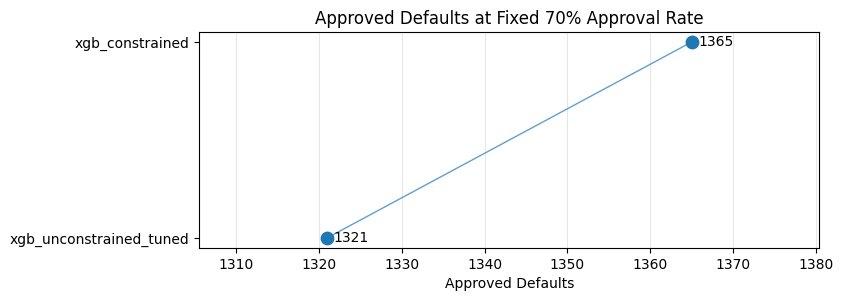

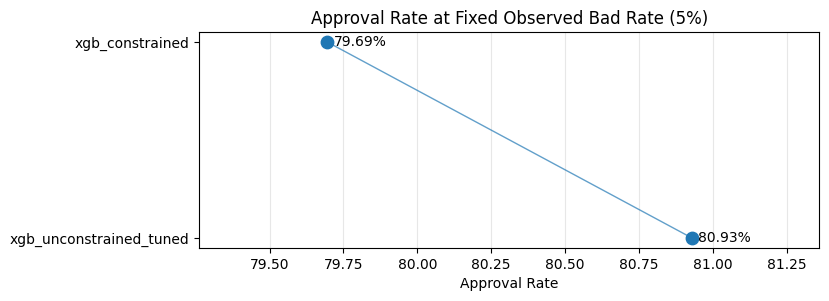

In [56]:
# Business-impact charts for presentation

# Chart 1: defaults approved at fixed approval rate
plot_two_model_comparison(
    compare_df=fixed_approval_compare_df,
    value_col="approved_defaults",
    title="Approved Defaults at Fixed 70% Approval Rate",
    x_label="Approved Defaults",
    as_percent=False,
    decimals=0
)

# Chart 2: approval rate at the selected fixed bad-rate target
plot_two_model_comparison(
    compare_df=selected_fixed_bad_rate_compare_df,
    value_col="approval_rate",
    title=f"Approval Rate at Fixed Observed Bad Rate ({SELECTED_BAD_RATE_TARGET:.0%})",
    x_label="Approval Rate",
    as_percent=True,
    decimals=2
)